# Classificação: Engajamento de Jogadores Online

O objetivo desse projeto é treinar modelos de classificação para prever engajamento de gamers online (High, Medium ou Low), como parte do MVP da pós-graduação em Engenharia de Software da PUC-Rio. O dataset veio do Kaggle (url: https://www.kaggle.com/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset). Os dados representam métricas de jogo, dados demográficos e comportamentos sociais(ex: idade, gênero, tempo gasto por sessão, frequência de sessões). O target é a coluna EngagementLevel, e vou usar os 4 algoritmos obrigatórios para esse MVP: KNN, Árvore de Classificação, Naive Bayes e SVM.


## Carga dos dados

Para garantir que qualquer pessoa consiga executar o notebook sem precisar baixar arquivos ou configurar nada, vou carregar o CSV pela url https://raw.githubusercontent.com/FernandaFranco/Gaming-Behavior/main/online_gaming_behavior_dataset.csv


In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/FernandaFranco/Gaming-Behavior/main/online_gaming_behavior_dataset.csv")
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [2]:
df.shape


(40034, 13)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [4]:
df['EngagementLevel'].value_counts()

,count
EngagementLevel,
Medium,19374
High,10336
Low,10324


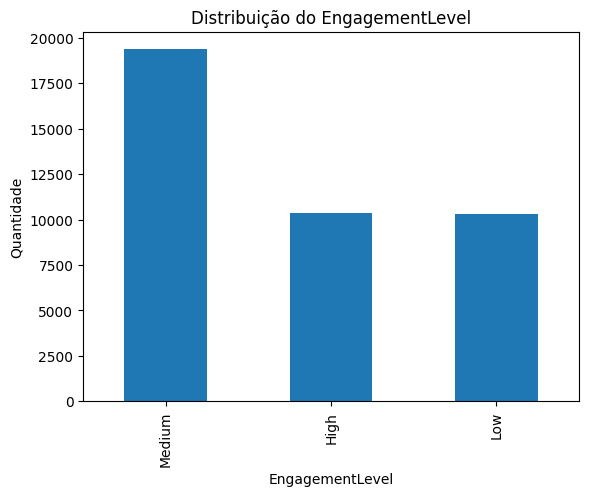

In [5]:
import matplotlib.pyplot as plt

df['EngagementLevel'].value_counts().plot(kind='bar')
plt.title('Distribuição do EngagementLevel')
plt.ylabel('Quantidade')
plt.show()

In [6]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


## EDA

* 40.034 registros, 13 colunas
* Zero valores faltantes
* 7 features numéricas, 4 features categóricas + 1 target + PlayerI(identificador)
* Target com leve desbalanceamento: Medium (\~48%), High (\~26%), Low (\~26%)



## Pré-Processamento

* Remover identificador, não tem relação com engajamento

In [7]:
df = df.drop('PlayerID', axis=1)

### Transformar as categóricas em números

* Label Encoding pras ordinais/binárias (Gender é binária; GameDifficulty tem ordem natural Easy < Medium < Hard)
* One-Hot pras nominais (não têm ordem natural entre os valores)

In [8]:
print(df['Gender'].unique())
print(df['Location'].unique())
print(df['GameGenre'].unique())
print(df['GameDifficulty'].unique())

['Male' 'Female']
['Other' 'USA' 'Europe' 'Asia']
['Strategy' 'Sports' 'Action' 'RPG' 'Simulation']
['Medium' 'Easy' 'Hard']


In [9]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['GameDifficulty'] = df['GameDifficulty'].map({'Easy': 0, 'Medium': 1, 'Hard': 2})
df

df = pd.get_dummies(df, columns=['Location'], dtype=int)
df = pd.get_dummies(df, columns=['GameGenre'], dtype=int)
df.head()

,Age,Gender,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Location_Asia,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,43,1,16.271119,0,1,6,108,79,25,Medium,0,0,1,0,0,0,0,0,1
1,29,0,5.525961,0,1,5,144,11,10,Medium,0,0,0,1,0,0,0,0,1
2,22,0,8.223755,0,0,16,142,35,41,High,0,0,0,1,0,0,0,1,0
3,35,1,5.265351,1,0,9,85,57,47,Medium,0,0,0,1,1,0,0,0,0
4,33,1,15.531945,0,1,2,131,95,37,Medium,0,1,0,0,1,0,0,0,0


Separação X e y (features vs target):

In [10]:
X = df.drop('EngagementLevel', axis=1)
y = df['EngagementLevel']

Split treino/teste (80/20) com random_state pra reprodutibilidade

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.shape

(32027, 18)

In [13]:
X_test.shape

(8007, 18)

Normalização com StandardScaler — fazer fit só no treino para evitar data leakage

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
print(X_train[:5])

[[ 0.40303595  0.82097605 -0.13858534 -0.50027319 -0.89671814 -1.29849195
  -0.13949949  1.26678096  1.34798476 -0.50329586 -0.65294586 -0.33080073
   1.22385304  1.99968782 -0.49929737 -0.49880931 -0.50246742 -0.49934617]
 [-1.68960907 -1.21806233 -0.50616721 -0.50027319  1.66132871  1.65295827
  -0.36412961 -0.55090293 -1.14660803  1.98690289 -0.65294586 -0.33080073
  -0.81709157  1.99968782 -0.49929737 -0.49880931 -0.50246742 -0.49934617]
 [-0.99206073 -1.21806233 -1.42574784 -0.50027319 -0.89671814  1.65295827
   0.43228627  0.1132508   0.93221929  1.98690289 -0.65294586 -0.33080073
  -0.81709157 -0.50007806  2.00281448 -0.49880931 -0.50246742 -0.49934617]
 [-0.49381191  0.82097605  0.89969478  1.99890783  1.66132871  0.26404052
   1.61669963 -0.55090293 -1.00801954 -0.50329586  1.53152055 -0.33080073
  -0.81709157 -0.50007806 -0.49929737  2.00477412 -0.50246742 -0.49934617]
 [ 0.70198524 -1.21806233  0.74988931 -0.50027319  0.38230528  1.47934355
   0.79986283  0.74244907  1.48657

In [16]:
print(X_test[:5])

[[ 1.69848287  0.82097605 -1.25564137  1.99890783  0.38230528  1.13211411
  -0.65002249 -0.2363038  -1.28519652 -0.50329586 -0.65294586  3.0229679
  -0.81709157  1.99968782 -0.49929737 -0.49880931 -0.50246742 -0.49934617]
 [-0.29451239 -1.21806233  1.10021194 -0.50027319  1.66132871  0.0904258
   0.08513063 -0.0615265  -0.9387253  -0.50329586 -0.65294586 -0.33080073
   1.22385304  1.99968782 -0.49929737 -0.49880931 -0.50246742 -0.49934617]
 [ 0.0044369   0.82097605  1.63435834 -0.50027319  0.38230528  0.26404052
  -1.58938481 -1.31992304  0.65504232  1.98690289 -0.65294586 -0.33080073
  -0.81709157 -0.50007806 -0.49929737 -0.49880931  1.9901788  -0.49934617]
 [ 1.69848287  0.82097605 -0.24073493 -0.50027319  0.38230528 -0.43041835
   1.10617663 -0.20134834  0.93221929  1.98690289 -0.65294586 -0.33080073
  -0.81709157  1.99968782 -0.49929737 -0.49880931 -0.50246742 -0.49934617]
 [ 1.5988331  -1.21806233 -0.83478037 -0.50027319 -0.89671814  0.0904258
   0.65691639 -1.25001212 -1.423785  

KNM:

In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [18]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

0.7063819158236543

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.74      0.72      0.73      2035
         Low       0.71      0.55      0.62      2093
      Medium       0.69      0.78      0.73      3879

    accuracy                           0.71      8007
   macro avg       0.71      0.69      0.70      8007
weighted avg       0.71      0.71      0.70      8007



Medium tem o melhor recall (0.78) — faz sentido, é a classe com mais exemplos
Low tem o recall mais fraco (0.55) — o modelo erra quase metade dos casos Low
High tá equilibrado (precision 0.74, recall 0.72)

In [20]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)

y_pred = decision_tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.8254027725739977

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.80      0.81      0.80      2035
         Low       0.78      0.80      0.79      2093
      Medium       0.86      0.85      0.86      3879

    accuracy                           0.83      8007
   macro avg       0.81      0.82      0.82      8007
weighted avg       0.83      0.83      0.83      8007



Low subiu de 0.55 (recall no KNN) pra 0.80 — uma melhora enorme. E todas as classes estão acima de 0.78, bem distribuído.

In [22]:
from sklearn.naive_bayes import GaussianNB

gaussian = GaussianNB()
gaussian.fit(X_train, y_train)

y_pred = gaussian.predict(X_test)
accuracy_score(y_test, y_pred)

0.8391407518421381

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.93      0.78      0.85      2035
         Low       0.90      0.68      0.78      2093
      Medium       0.79      0.95      0.86      3879

    accuracy                           0.84      8007
   macro avg       0.87      0.81      0.83      8007
weighted avg       0.85      0.84      0.84      8007



In [ ]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

 melhor performance, mas mais custo computacional.

In [ ]:
print(classification_report(y_test, y_pred))

o panorama completo:


| Modelo      | Acurácia | F1 (High) | F1 (Low) |F1 (Medium) |
|-------------|----------|-----------|----------|------------|
| KNN         | 70.6%    | 0.73      | 0.62     | 0.73       |
| Árvore      | 82.5%    | 0.80      | 0.79     | 0.86       |
| Naive Bayes | 83.9%    | 0.85      | 0.78     | 0.86       |
| SVM         | 88.4%    | 0.88      | 0.86     | 0.90       |




Testar combinações de hiperparâmetros usando cross-validation:

## KNN:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_knn.fit(X_train, y_train)

In [ ]:
print(grid_knn.best_params_)
print(grid_knn.best_score_)

## Árvore de Classificação:

In [ ]:
param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_dtc = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_dtc.fit(X_train, y_train)

In [ ]:
print(grid_dtc.best_params_)
print(grid_dtc.best_score_)

## Naive Bayes:

In [ ]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_gnb = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_gnb.fit(X_train, y_train)
print(grid_gnb.best_params_)
print(grid_gnb.best_score_)

o Naive Bayes já estava na melhor configuração

## SVM:

In [ ]:
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10]
}

grid_svc = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_svc.fit(X_train, y_train)
print(grid_svc.best_params_)
print(grid_svc.best_score_)

panorama após otimização:
|Modelo      |Antes |Depois |Melhor parâmetro                   |
|------------|------|-------|-----------------------------------|
|KNN         |70.6% |72.9%  |n_neighbors=11                     |
|Árvore      |82.5% |89.9%  |max_depth=10, min_samples_split=10 |
|Naive Bayes |83.9% |83.9%  |padrão (1e-9)                       |
|SVM         |88.4% |88.5%  |padrão (rbf, C=1)                  |

Arvore otimizada:

In [ ]:
y_pred = grid_dtc.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

KNN otimizado:

In [ ]:
y_pred = grid_knn.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

Panorama final:

| Modelo | Acurácia | F1 High | F1 Low | F1 Medium |
|---|---|---|---|---|
| KNN otimizado | 74% | 0.76 | 0.63 | 0.77 |
| Naive Bayes | 83.9% | 0.85 | 0.78 | 0.86 |
| SVM otimizado | 88.5% | 0.88 | 0.86 | 0.90 |
| **Árvore otimizada** | **90%** | **0.89** | **0.87** | **0.91** |

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = grid_dtc.best_estimator_.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Matriz de Confusão - Árvore Otimizada')
plt.show()



* A diagonal (1788, 1764, 3620) são os acertos — bem forte nas três classes
* O erro mais frequente é classificar Low como Medium (252 casos) — faz sentido porque Medium é a classe majoritária, o modelo tende a "puxar" pra lá
* High é a classe mais bem classificada (1788 de 2035)



Exportando o melhor modelo:

In [ ]:
import pickle

with open('modelo.pkl', 'wb') as f:
    pickle.dump(grid_dtc.best_estimator_, f)

# salvando o scaler tambem:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

## Análise de Resultados e Conclusão

O objetivo deste projeto foi treinar modelos de classificação para prever o nível de engajamento (High, Medium ou Low) de jogadores online, utilizando dados demográficos e métricas de jogo.

Foram treinados 4 modelos: KNN, Árvore de Classificação, Naive Bayes e SVM. Todos superaram o baseline de ~48% (que seria chutar sempre "Medium"), o que indica que as features do dataset têm relação com o nível de engajamento.

Após a otimização de hiperparâmetros com GridSearchCV (cv=5), o modelo que apresentou melhor desempenho foi a Árvore de Classificação, com acurácia de 90%. A otimização teve maior impacto nesse modelo porque limitar a profundidade da árvore (max_depth=10) evitou overfitting — sem esse limite, a árvore "decora" os dados de treino e generaliza mal.

Um ponto interessante foi que a Árvore ultrapassou o SVM após a otimização, apesar do SVM ter sido superior com parâmetros padrão. Outro destaque é que o KNN teve dificuldade consistente com a classe Low (recall de 0.53), mesmo após otimização.

Como pontos de atenção, destaco:
- O target apresenta leve desbalanceamento (~48% Medium vs ~26% High e Low), o que pode favorecer predições para a classe Medium
- O SVM teve custo computacional significativamente maior que os demais modelos, especialmente na etapa de otimização

O modelo escolhido para exportação e integração na aplicação full stack foi a Árvore de Classificação otimizada (max_depth=10, min_samples_split=10).
A matriz de confusão mostra que o principal erro do melhor modelo é classificar jogadores Low como Medium, o que pode estar relacionado ao leve desbalanceamento do target.